# Analysis Pipeline

## 0 Introduction

### Objective

This project constructs an annotation dataset to analyze linguistic strategies and their relationship with perceived emotional support in educational dialogue.

The workflow includes data preprocessing, annotation, and statistical analysis, with a focus on how different response types influence perceived support.

The repository is organized as a structured pipeline, from raw data preparation to final analysis.

## 0 Data Availability

The dataset used in this project is not publicly available due to restrictions imposed by the data provider.

Researchers interested in accessing the data should contact the original provider and obtain the necessary permissions:  
https://sig-edu.org/sharedtask/2023

Upon approval, I am happy to provide guidance and share the data processing scripts to help reproduce the analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 1 Perceived Emotional Support Scoring

### 1.1 Annotator A

In [2]:
df = pd.read_csv("annot_data_full.csv", sep=";", engine="python")

In [3]:
annot_A = df.drop(columns=["Unnamed: 0"])
annot_A.rename(columns={"support_score": "support_A"}, inplace=True)
annot_A.head()

,id,context,teacher_response,support_A
0,train_2679,"Wether Almost. Whether WH - like when, where, ...",Which month is your birthday?,1
1,train_2520,At 6 And why are you only going to be studying...,"and, of course, because children are much more...",3
2,train_2094,sorry I mean if you only say that exercise is ...,ah ok! So if this is your 'thesis' then you sh...,3
3,train_0566,"I see! It all makes sense, thank you very much...",Ok and after that some funny fact about me,2
4,train_2241,"It is hot outside It's very hot here today, by...","Ah, I'm with you. I have to stay at home, too!",5


### 1.2 Annotator B

In [4]:
df_part1 = pd.read_csv("annot_data_part1.csv")
annot_B = df_part1.drop(columns=["Unnamed: 0"])
annot_B = annot_B.rename(columns={"support_score": "support_B"})
annot_B.head()

,id,context,teacher_response,support_B
0,train_2679,"Wether Almost. Whether WH - like when, where, ...",Which month is your birthday?,1
1,train_2520,At 6 And why are you only going to be studying...,"and, of course, because children are much more...",3
2,train_2094,sorry I mean if you only say that exercise is ...,ah ok! So if this is your 'thesis' then you sh...,1
3,train_0566,"I see! It all makes sense, thank you very much...",Ok and after that some funny fact about me,1
4,train_2241,"It is hot outside It's very hot here today, by...","Ah, I'm with you. I have to stay at home, too!",3


### 1.3 Annotator C

In [5]:
df_part2 = pd.read_csv("annot_data_part2.csv")
annot_C = df_part2.drop(columns=["Unnamed: 0"])
annot_C = annot_C.rename(columns={"support_score": "support_C"})
annot_C.head()

,id,context,teacher_response,support_C
0,train_0782,"sorry, I meant present perfect simple when I w...","well, in the present perfect the auxiliary is ...",2
1,train_2598,I understand! And where do you watch Spanish p...,yes are they still dubbed (the English languag...,1
2,train_0441,add a leeter to make it an adverb a letter i ...,OK ....however...let's have a think about the ...,3
3,train_0509,"thanks ,I got it OK the site froze for me for ...",Yes that's ok - I think it was the site actual...,2
4,train_0077,easy right? Just under a one third of people c...,OK I'll catch up with you in the week - thanks...,4


### 1.4 Data Merging

In [6]:
merged = annot_A.merge(
    annot_B[["id", "support_B"]],
    on="id",
    how="left"
).merge(
    annot_C[["id", "support_C"]],
    on="id",
    how="left"
)

In [7]:
merged.head()

,id,context,teacher_response,support_A,support_B,support_C
0,train_2679,"Wether Almost. Whether WH - like when, where, ...",Which month is your birthday?,1,1.0,NaN
1,train_2520,At 6 And why are you only going to be studying...,"and, of course, because children are much more...",3,3.0,NaN
2,train_2094,sorry I mean if you only say that exercise is ...,ah ok! So if this is your 'thesis' then you sh...,3,1.0,NaN
3,train_0566,"I see! It all makes sense, thank you very much...",Ok and after that some funny fact about me,2,1.0,NaN
4,train_2241,"It is hot outside It's very hot here today, by...","Ah, I'm with you. I have to stay at home, too!",5,3.0,NaN


In [8]:
merged.isna().sum()

id                    0
context               0
teacher_response      0
support_A             0
support_B           252
support_C           251
dtype: int64

### 1.5 Data Cleaning and Validation

In [9]:
import numpy as np
merged = merged.replace(r"^\s*#\s*$", np.nan, regex=True)

cols = ["support_A", "support_B", "support_C"]
for col in cols:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

cols = ["support_A", "support_B", "support_C"]
for col in cols:
    merged[col] = merged[col].replace(0, 1)

In [10]:
merged[cols].head()

,support_A,support_B,support_C
0,1,1.0,NaN
1,3,3.0,NaN
2,3,1.0,NaN
3,2,1.0,NaN
4,5,3.0,NaN


In [11]:
merged.isna().sum()

id                    0
context               0
teacher_response      0
support_A             0
support_B           252
support_C           253
dtype: int64

### 1.6 Inter Annotator Agreement

In [12]:
ab = merged.drop(columns=["support_C"])
ac= merged.drop(columns=["support_B"])
ab["diff_A_B"] = (ab["support_A"] - ab["support_B"]).abs()
ac["diff_A_C"] = (ac["support_A"] - ac["support_C"]).abs()

In [13]:
count_diff_ab = ab["diff_A_B"].value_counts().sort_index()
percentage_diff_ab = ab["diff_A_B"].value_counts(normalize=True).sort_index()
result_diff_ab = pd.DataFrame(
   { "Count": count_diff_ab,
    "Percentage(%)": percentage_diff_ab * 100}
)
print(result_diff_ab.round(2))

          Count  Percentage(%)
diff_A_B                      
0.0          66          26.29
1.0         104          41.43
2.0          68          27.09
3.0          13           5.18


In [14]:
count_diff_ac = ac["diff_A_C"].value_counts().sort_index()
percentage_diff_ac = ac["diff_A_C"].value_counts(normalize=True).sort_index()
result_diff_ac = pd.DataFrame(
   { "Count": count_diff_ac,
    "Percentage(%)": percentage_diff_ac * 100}
)
print(result_diff_ac.round(2))

          Count  Percentage(%)
diff_A_C                      
0.0          57           22.8
1.0          99           39.6
2.0          81           32.4
3.0          12            4.8
4.0           1            0.4


In [15]:
df_plot = pd.DataFrame({
    "diff": percentage_diff_ab.index,
    "AB": percentage_diff_ab.values *100,
    "AC": percentage_diff_ac.reindex(percentage_diff_ab.index, fill_value=0).values * 100
})
df_plot = df_plot.melt(id_vars="diff", var_name="Pair", value_name="Percentage")

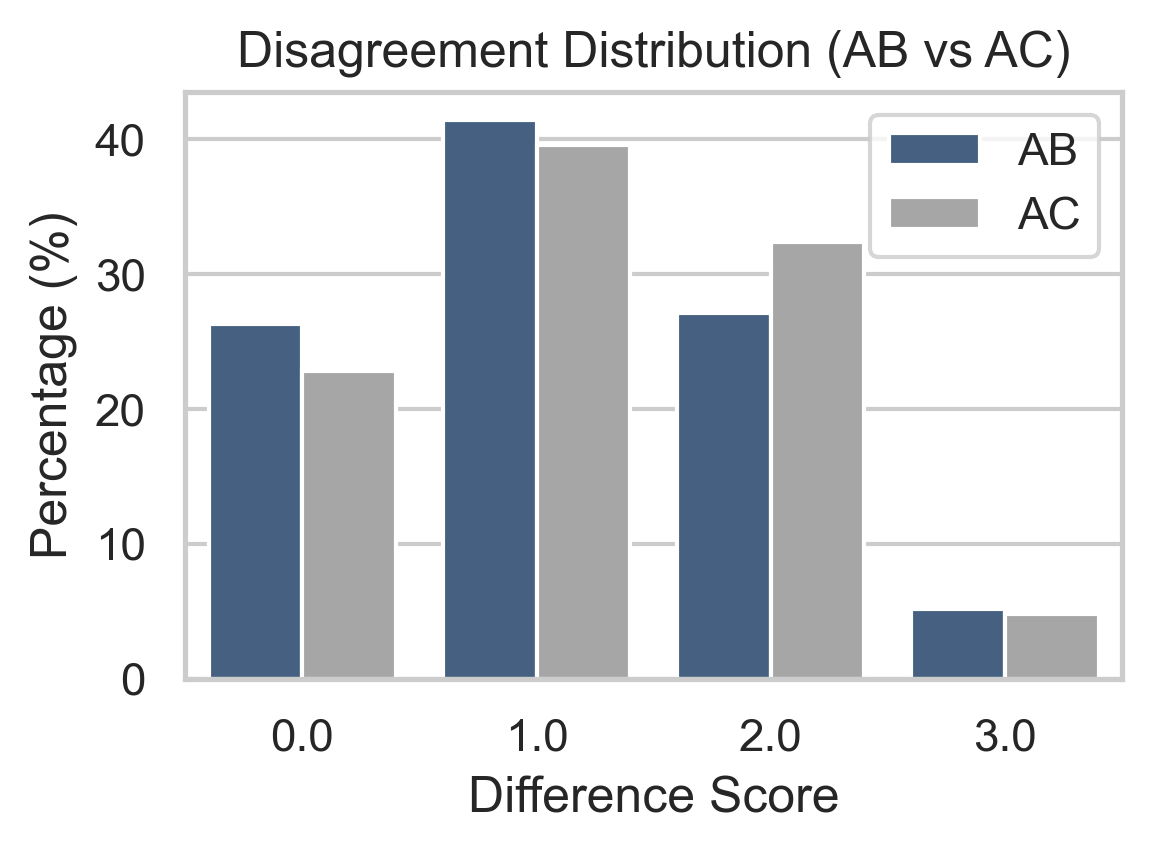

In [16]:
sns.set(style="whitegrid")

plt.figure(figsize=(4,3), dpi=300)

palette = {
    "AB": "#3B5F8A",
    "AC": "#A6A6A6"
}

sns.barplot(
    data=df_plot,
    x="diff",
    y="Percentage",
    hue="Pair",
    palette=palette
)

plt.title("Disagreement Distribution (AB vs AC)")
plt.xlabel("Difference Score")
plt.ylabel("Percentage (%)")

plt.legend(title="")
plt.tight_layout()

plt.show()

`Summary`

The distribution of score differences indicates a generally moderate level of agreement between annotators. Most ratings differ by 1 point (≈40%), followed by exact agreement (0 difference, ≈20–25%). Larger discrepancies (≥2 points) are less frequent, and differences of 3 or more are rare.

This pattern suggests that annotators broadly share similar judgments of perceived support, while still allowing for some variation due to the subjective nature of the task.

In [17]:
import pandas as pd

pd.set_option("display.max_colwidth", None)

In [18]:
ab_extreme = ab[ab["diff_A_B"] >= 3]
ab_extreme

,id,context,teacher_response,support_A,support_B,diff_A_B
20,train_2743,"Yes, it feels like that I'm alright, it seems we are going to start going out soon... So happy about it how about you? Yes I can imagine - I wonder what it will be like? I mean will things feel different for a while?",Yes I'm fine thanks - to be perfectly honest I'm quite a self-contained person (well that's one word for it!) so the whole lockdown thing has not really affected me that much,1,4.0,3.0
47,train_2179,"Right I see...yes I'd really like to go for a run too. I normally run a lot but I have a knee injury at the moment. Ironically, I'd be stuck inside anyway even without this virus! So you just have to stay in a room all day? How do you get your meals? yes, I know you said it before. without doubt, it will be my most memorable 28 days,","Yes,,you'll look back on it with nostalgia ....",1,4.0,3.0
49,train_0464,"Or sorry look at the Australia one oh, Sorry We but your France one was correct Coal generated 130 units of electricity in Australia in 2000 Or 130 units of electricity was generated from coal inAustralia in2000 yes that's great <STUDENT> ...can you try a use a fraction? what's it closer to half/two thirds/three quarters? Coal generated just over th Three quarters",yes ok good so: 'Coal generated more than three quarters of electricity in Australia in 2000' = good,2,5.0,3.0
51,train_2487,"yes that's it! Suddenly I have a silly doubt go ahead.... Do we use 'meet with' to talk about meeting someone in the street or in a similar situation? yeah good question...so, in the UK we usually use no preposition e.g. can I meet you later? but in the US they see meet with you (I'm nore sure if they always do to be honest but they definitely do sometimes! not sure",at least a lot more than in the UK,2,5.0,3.0
62,train_0179,"Your turn in a minute! Do you know the word for 'travel to work regularly'? Travel to work? I have no idea Commute He commutes to work (or at least he did before the quarantine) Ok Do you commute to school in Kyiv or are do you walk? I commute to school sorry, 'or do you walk?', without 'are'","Ok, do you commute by underground?",1,4.0,3.0
73,train_2361,"Have you followed any of the news in English? Yes, I follow BBC News on facebook so everyday I read something, at least the headlines Finally your president in not in intensive care whatever haha I don't know the words OK right - very conscientious of you - so yeah , you'll have picked up all the phrases we use....it's all good vocabulary no , intensive care = perfectly correct",yes he's out now...so i guess he'll recover,2,5.0,3.0
80,train_2151,yes good that's the key right? It's called 'noticing' in language teaching (not a very technical term i know!) Ah no I haven't heard of that but I'll look out for it It's on Netflix I don't normally watch Spanish TV by the way - it's only because we recently upgraded the tech on our boat (due to having work from home),so I can now get a good enough signal to constantly stream unlimited data,2,5.0,3.0
148,train_2112,Yes OK great! So even though of course 'the making' happened in the past in a way we are focused on NOW That's why it's called the 'present' perfect OK one final final test(!): 'Video games have become/became more and more popular....' Which one is best? wow... I think I understand the logic of 'present' OK good....,Which intro is probably best for an IELTS essay?,1,4.0,3.0
163,train_0359,"Do you know what I mean? yes good Next one! A stick that wizards can use to do magic is called... magic wand correct! If a wizard cooks some mixture that has magical powers, this mixture is called... ? a potion oops sorry Professor Snape was teaching Potions as you remember no worries, I know this programme does this if the Internet blips yes","Ok, what do we call a big pot for making potions?",2,5.0,3.0
165,train_0103,"Yeah, I understand Some people live in flats, especially in big cities, and flats are usually on one level. Which is probably why 

In [19]:
ac_extreme = ac[ac["diff_A_C"] >= 3]
ac_extreme

,id,context,teacher_response,support_A,support_C,diff_A_C
284,train_2259,My idea is to take the Cambridge Advanced exam in February so I have to work on it everyday... It's hard thoug +though,"yeah that's great - there's so much now right? I've really noticed the effect on the average level of my students, especially the younger ones - they've picked up so much from the internet etc - that's great about CAE - it's good to have a set goal I guess...",5,2.0,3.0
286,train_2107,so all the staff will probably be laid off Yes that's true I guess - that's what everyone's doing but as you say the demand won't necessarily be there right now - we'l see! I'm planning lots of quality time at my allotment... That sounds like a very good plan Here you couldn't go to your allotment either!,THat's definitely over the top! I think that would never happen in the UK!,4,1.0,3.0
372,train_0424,"determined→I don't know That's OK - choose one you know... self-confident→ over confident?? Good idea! Yes absolutely it's possible...maybe we use it often for one occasion. More generally we might say arrogant Do another one if you can... Hmmm. No, I can't.",OK no problem - I'll give you some examples and you tell me which one they match with OK? weird,4,1.0,3.0
373,train_1537,"thanks for every time helping me to study basic grammar stuffs! yes, let' start That's OK we can do more of the basic grammar stuff too all right?! yes! OK so the thi s is the idea: Video games have a range of negative effects and playing them should be discouraged. To what extent do you agree?",Any main idea you could include for this? Don't worry about the language too much ...just a quick basic idea if you can...,5,1.0,4.0
387,train_2420,So: It is often argued that the most effective way to lead a less stressful lifestyle is __ rent a house.?? to OR house rental.,OK thanks <STUDENT> - yes good,2,5.0,3.0
401,train_1356,"Yes Makes sense So you'll just have to give it some food? Some bugs Yuck! Give some water I'm not really disgusted by bugs, I live in the country and garden a lot :) And probably keep it warm? Yes I don't like snails you must hnow why Why? Oh you don't now? Because they have slime And bugs are dry",Slugs and snails are my chief enemies because they eat my plants!,2,5.0,3.0
405,train_0332,"Hi <STUDENT>... Hi <TEACHER> Feels like a while since I spoke to you - how's it going? Yes, it feels like that I'm alright, it seems we are going to start going out soon... So happy about it how about you? Yes I can imagine - I wonder what it will be like?",I mean will things feel different for a while?,4,1.0,3.0
412,train_0352,"good afternoon <TEACHER>. Hi there <STUDENT>, how's it going? yes... I just feel tired when when want to study massive new knowledge. it is difficult to see improvement of myself. because they all hard for me,.",OK...you mean you feel overwhelmed by the huge task in front of you? You mean improving your English?,4,1.0,3.0
415,train_0288,You can do them in any order ok? And you can just give me one answer at a time or I'll wait for all ten - I don't mind OK? ok.. I will write all answers OK 1. policy 2.inherit 3.readership 4.bullying 5.brith 6.example 7.unafordable 8.violence 9.innate 10. 10.violent,OK thanks a lot <STUDENT> - very good. So I agree that 10. = violent.....so number 4 = ?,2,5.0,3.0
436,train_2712,"sure OK the kindling has caught this time... I sit warm where you are at the moment? is it warm i mean! Sorry, I don't understand... kindling?? Ah yes sorry - it's the name for the little bits of wood or whatever you use to start the fire at the beginning Here 18 degrees now, during the day it's very sunny",NIce....yes it's actually really sunny this week here too - and maybe....13 degrees!,2,5.0,3.0


### 1.7 Score Aggregation (Mean)

In [20]:
score_agg = merged.copy()
score_agg["support_avg"] = score_agg[["support_A", "support_B", "support_C"]].mean(axis=1)
score_agg.head()

,id,context,teacher_response,support_A,support_B,support_C,support_avg
0,train_2679,"Wether Almost. Whether WH - like when, where, what etc. Aha Ok, cool, you sound more confident with this material today, right? Yes Cool. I've got something for today, some bits of it will probably be very familiar, but some maybe new My birthday is __ March. We talked __ Skype. She's always ___ her phone. Could you insert some prepositions please? On march on Skype on her phone 43892.0 in March",Which month is your birthday?,1,1.0,NaN,1.0
1,train_2520,"At 6 And why are you only going to be studying for 11 years? It's our old programme and all children who went to school 2 years ago study for 12 years I see! It's a new rule then! Very interesting I went to school at 7 I see, me too! I think 7 is a good age to start school. Because you get 7 years of freeeedom :) Not really","and, of course, because children are much more mature at 7",3,3.0,NaN,3.0
2,train_2094,sorry I mean if you only say that exercise is the most importnatn thing So for example...in your opinion is diet as important as exercise or less important ? as important as exercise,ah ok! So if this is your 'thesis' then you should say that in the intro...hold on...,3,1.0,NaN,2.0
3,train_0566,"I see! It all makes sense, thank you very much! Also, really well done with all the writing today! But you still need to see gameplay Oh I will now, thank you. It'll be my homework :) Now, let's have a go at some sentences I copied from the chat. Could you insert the missing word? It's pretty warm with cat The cat? Yes, correct!",Ok and after that some funny fact about me,2,1.0,NaN,1.5
4,train_2241,"It is hot outside It's very hot here today, by English standards. +29 Wow I am okay, but I don’t know what to do What do you mean? Like Are you a bit confused about this lesson? or generally, you are not sure what to do with your time? Be a of the karantine, I can’t go somewhere So I am sitting at home And it is terrible","Ah, I'm with you. I have to stay at home, too!",5,3.0,NaN,4.0


## 2 Teacher Response Type Annotation

In [21]:
df = pd.read_csv("teacher_type_of_response_annotation.csv", sep=";", engine="python")
df = df.drop(columns=["Unnamed: 0"])

### 2.1 Coverage of Response Type Annotation

In [22]:
type_response = df[[
    "id",
    "teacher_response",
    "TR_Empathy",
    "TR_Encouragement",
    "TR_Explanation",
    "TR_Directive"
]].copy()

type_response["TR_total"] = type_response[
    ["TR_Empathy", "TR_Encouragement", "TR_Explanation", "TR_Directive"]
].sum(axis=1)

type_response["type_status"] = type_response["TR_total"].apply(
    lambda x: "No labeled" if x == 0 else "labeled at least one"
)

type_response.head()


,id,teacher_response,TR_Empathy,TR_Encouragement,TR_Explanation,TR_Directive,TR_total,type_status
0,train_2679,Which month is your birthday?,0,0,0,1,1,labeled at least one
1,train_2520,"and, of course, because children are much more mature at 7",1,0,0,0,1,labeled at least one
2,train_2094,ah ok! So if this is your 'thesis' then you should say that in the intro...hold on...,0,0,0,1,1,labeled at least one
3,train_0566,Ok and after that some funny fact about me,0,0,0,1,1,labeled at least one
4,train_2241,"Ah, I'm with you. I have to stay at home, too!",1,0,0,0,1,labeled at least one


In [23]:
# Calculate the number of responses with and without assigned response types
type_status_table = (
    type_response["type_status"]
    .value_counts()
    .rename_axis("Response Type Status")
    .reset_index(name="Count")
)

type_status_table["Percentage (%)"] = (
    type_status_table["Count"] / len(type_response) * 100
).round(2)

type_status_table

,Response Type Status,Count,Percentage (%)
0,labeled at least one,315,62.62
1,No labeled,188,37.38


In [24]:
# type of response: frequency
TR_count = type_response[[
    "TR_Empathy",
    "TR_Encouragement",
    "TR_Explanation",
    "TR_Directive"
]].sum()

# type of response: percentage
TR_percentage = type_response[[
    "TR_Empathy",
    "TR_Encouragement",
    "TR_Explanation",
    "TR_Directive",
]].mean() * 100 

# number of different types per response
TR_per_response = type_response["TR_total"].value_counts().sort_index()

### 2.2 Distribution of Response Types

In [25]:
# Calculate the count and percentage of each response type
TR_cols = [
    "TR_Empathy",
    "TR_Encouragement",
    "TR_Explanation",
    "TR_Directive"
]

summary_table = pd.DataFrame({
    "Count": TR_count,
    "Percentage (%)": TR_percentage.round(2)
})

# Include responses not assigned to any predefined type
no_labeled_count = (type_response["TR_total"] == 0).sum()
no_labeled_percentage = round(no_labeled_count / len(type_response) * 100, 2)

no_labeled_row = pd.DataFrame({
    "Count": [no_labeled_count],
    "Percentage (%)": [no_labeled_percentage]
}, index=["No labeled"])

summary_table_full = pd.concat([summary_table, no_labeled_row])

summary_table_full

,Count,Percentage (%)
TR_Empathy,38,7.55
TR_Encouragement,63,12.52
TR_Explanation,129,25.65
TR_Directive,116,23.06
No labeled,188,37.38


### 2.3 Distribution of Multiple Response Types

In [26]:
# multiple Types of Response 
multi_TR = (
    type_response[type_response["TR_total"] > 0]["TR_total"]
    .value_counts()
    .sort_index()
    .rename_axis("Type")
    .reset_index(name="Count")
)

multi_TR["Percentage (%)"] = (
    multi_TR["Count"] / len(type_response["TR_total"]) * 100
).round(2)

multi_TR = multi_TR.set_index("Type")
multi_TR

,Count,Percentage (%)
Type,,
1,285,56.66
2,29,5.77
3,1,0.20


## 3 Relationship Between Response Types and Perceived Support

In [27]:
type_response = type_response.merge(
    score_agg[["id", "support_avg"]],
    on="id",
    how="left"
)
type_response.head()

,id,teacher_response,TR_Empathy,TR_Encouragement,TR_Explanation,TR_Directive,TR_total,type_status,support_avg
0,train_2679,Which month is your birthday?,0,0,0,1,1,labeled at least one,1.0
1,train_2520,"and, of course, because children are much more mature at 7",1,0,0,0,1,labeled at least one,3.0
2,train_2094,ah ok! So if this is your 'thesis' then you should say that in the intro...hold on...,0,0,0,1,1,labeled at least one,2.0
3,train_0566,Ok and after that some funny fact about me,0,0,0,1,1,labeled at least one,1.5
4,train_2241,"Ah, I'm with you. I have to stay at home, too!",1,0,0,0,1,labeled at least one,4.0


### 3.1 Descriptive Results

#### 3.1.1  Effects of Individual Response Types (Mean)
        (Empathy, Encouragement, Explanation, Directive)

In [28]:
# Empathy

TR_Em_score = (
    type_response
    .groupby("TR_Empathy", as_index=False)
    .agg(Average_Support_Score=("support_avg", "mean"))
)

TR_Em_score["TR_Empathy"] = TR_Em_score["TR_Empathy"].map({
    0: "Not Used",
    1: "Used"
})

TR_Em_score.round(2)

,TR_Empathy,Average_Support_Score
0,Not Used,3.12
1,Used,3.64


In [29]:
# Encouragement

TR_Ec_score = (
    type_response
    .groupby("TR_Encouragement", as_index=False)
    .agg(Average_Support_Score=("support_avg", "mean"))
)

TR_Ec_score["TR_Encouragement"] = TR_Ec_score["TR_Encouragement"].map({
    0: "Not Used",
    1: "Used"
})

TR_Ec_score.round(2)

,TR_Encouragement,Average_Support_Score
0,Not Used,3.08
1,Used,3.73


In [30]:
# Explanation

TR_Ex_score = (
    type_response
    .groupby("TR_Explanation", as_index=False)
    .agg(Average_Support_Score=("support_avg", "mean"))
)

TR_Ex_score["TR_Explanation"] = TR_Ex_score["TR_Explanation"].map({
    0: "Not Used",
    1: "Used"
})

TR_Ex_score.round(2)

,TR_Explanation,Average_Support_Score
0,Not Used,3.13
1,Used,3.26


In [31]:
# Directive

TR_Dr_score = (
    type_response
    .groupby("TR_Directive", as_index=False)
    .agg(Average_Support_Score=("support_avg", "mean"))
)

TR_Dr_score["TR_Directive"] = TR_Dr_score["TR_Directive"].map({
    0: "Not Used",
    1: "Used"
})

TR_Dr_score.round(2)

,TR_Directive,Average_Support_Score
0,Not Used,3.27
1,Used,2.80


In [32]:
summary_table = pd.DataFrame({
    "Response Type": ["Empathy", "Encouragement", "Explanation", "Directive"],
    "Used": [
        TR_Em_score.loc[TR_Em_score["TR_Empathy"] == "Used", "Average_Support_Score"].values[0],
        TR_Ec_score.loc[TR_Ec_score["TR_Encouragement"] == "Used", "Average_Support_Score"].values[0],
        TR_Ex_score.loc[TR_Ex_score["TR_Explanation"] == "Used", "Average_Support_Score"].values[0],
        TR_Dr_score.loc[TR_Dr_score["TR_Directive"] == "Used", "Average_Support_Score"].values[0],
    ],
    "Not Used": [
        TR_Em_score.loc[TR_Em_score["TR_Empathy"] == "Not Used", "Average_Support_Score"].values[0],
        TR_Ec_score.loc[TR_Ec_score["TR_Encouragement"] == "Not Used", "Average_Support_Score"].values[0],
        TR_Ex_score.loc[TR_Ex_score["TR_Explanation"] == "Not Used", "Average_Support_Score"].values[0],
        TR_Dr_score.loc[TR_Dr_score["TR_Directive"] == "Not Used", "Average_Support_Score"].values[0],
    ]
}).round(2)

summary_table.set_index("Response Type")

,Used,Not Used
Response Type,,
Empathy,3.64,3.12
Encouragement,3.73,3.08
Explanation,3.26,3.13
Directive,2.80,3.27


#### 3.1.2 Effects of Response Type Combinations (Mean)
    (No labeled types, Overall average, Multiple types, Single type)

In [33]:
# No labeled types
no_label_counts = type_response[type_response["TR_total"] == 0]["support_avg"].count()
no_label_score = type_response[type_response["TR_total"] == 0]["support_avg"].mean().round(2)
print ("The amount of responses aren't be annotated: ", no_label_counts)
print("The score of responses aren't be annotated: ", no_label_score)

The amount of responses aren't be annotated:  188
The score of responses aren't be annotated:  3.13


In [34]:
# Overall Average Support Score
total_counts = type_response["id"].count()
overall_score = type_response["support_avg"].mean().round(2)
print ("The total of responses: ", total_counts)
print("The score of overall average: ",overall_score)

The total of responses:  503
The score of overall average:  3.16


In [35]:
# Multiple types
multi_counts = type_response[type_response["TR_total"] > 1]["support_avg"].count()
multi_score = type_response[type_response["TR_total"] > 1]["support_avg"].mean().round(2)
print ("The responses annotated by multiple types are: ", multi_counts)
print("The score of multiple annotated responses: ",multi_score)

The responses annotated by multiple types are:  30
The score of multiple annotated responses:  3.73


In [36]:
# Combinations of Multiple types
multi = type_response[type_response["TR_total"] > 1].copy()

multi["combination"] = multi[
    ["TR_Empathy", "TR_Encouragement", "TR_Explanation", "TR_Directive"]
].apply(lambda x: tuple(x.index[x == 1]), axis=1)

combo_counts = multi["combination"].value_counts().reset_index()
combo_counts.columns = ["Combination", "Count"]

combo_counts["Combination"] = combo_counts["Combination"].apply(
    lambda x: ", ".join([i.replace("TR_", "") for i in x])
)

combo_counts["Percentage"] = (
    combo_counts["Count"] / combo_counts["Count"].sum() * 100
).round(1)

combo_counts

combo_counts.set_index("Combination")

,Count,Percentage
Combination,,
"Encouragement, Directive",11,36.7
"Encouragement, Explanation",9,30.0
"Empathy, Explanation",4,13.3
"Empathy, Encouragement",2,6.7
"Explanation, Directive",2,6.7
"Empathy, Explanation, Directive",1,3.3
"Empathy, Directive",1,3.3


In [37]:
# Single value type
single_value = type_response[type_response["TR_total"] == 1]["support_avg"].mean().round(2)
single_value

np.float64(3.12)

#### 3.1.3 Summary Comparison of Conditions

##### 3.1.3.1 Average Support Scores Across Conditions  

In [ ]:
# Comparison of Average Score Base on the Response Type and Condition

comparison_table = pd.DataFrame({
    "Response Type": [
        "Empathy", "Empathy",
        "Encouragement", "Encouragement",
        "Explanation", "Explanation",
        "Directive", "Directive",
        "No Labeled",
        "Single Type",
        "Multiple Types",
        "Overall"
    ],
    "Condition": [
        "Used", "Not Used",
        "Used", "Not Used",
        "Used", "Not Used",
        "Used", "Not Used",
        "",
        "",
        "",
        ""
    ],
    "Average Support Score": [
        TR_Em_score.loc[TR_Em_score["TR_Empathy"] == "Used", "Average_Support_Score"].values[0],
        TR_Em_score.loc[TR_Em_score["TR_Empathy"] == "Not Used", "Average_Support_Score"].values[0],

        TR_Ec_score.loc[TR_Ec_score["TR_Encouragement"] == "Used", "Average_Support_Score"].values[0],
        TR_Ec_score.loc[TR_Ec_score["TR_Encouragement"] == "Not Used", "Average_Support_Score"].values[0],

        TR_Ex_score.loc[TR_Ex_score["TR_Explanation"] == "Used", "Average_Support_Score"].values[0],
        TR_Ex_score.loc[TR_Ex_score["TR_Explanation"] == "Not Used", "Average_Support_Score"].values[0],

        TR_Dr_score.loc[TR_Dr_score["TR_Directive"] == "Used", "Average_Support_Score"].values[0],
        TR_Dr_score.loc[TR_Dr_score["TR_Directive"] == "Not Used", "Average_Support_Score"].values[0],

        no_label_score,
        single_value,
        multi_score,
        overall_score
    ]
}).round(2)

comparison_table.set_index("Response Type")

,Condition,Average Support Score
Response Type,,
Empathy,Used,3.64
Empathy,Not Used,3.12
Encouragement,Used,3.73
Encouragement,Not Used,3.08
Explanation,Used,3.26
Explanation,Not Used,3.13
Directive,Used,2.80
Directive,Not Used,3.27
No Labeled,,3.13


In [65]:
# Preparation for the Visualization
plot_df = comparison_table[
    comparison_table["Response Type"].isin(["Empathy", "Encouragement", "Explanation", "Directive"])
]

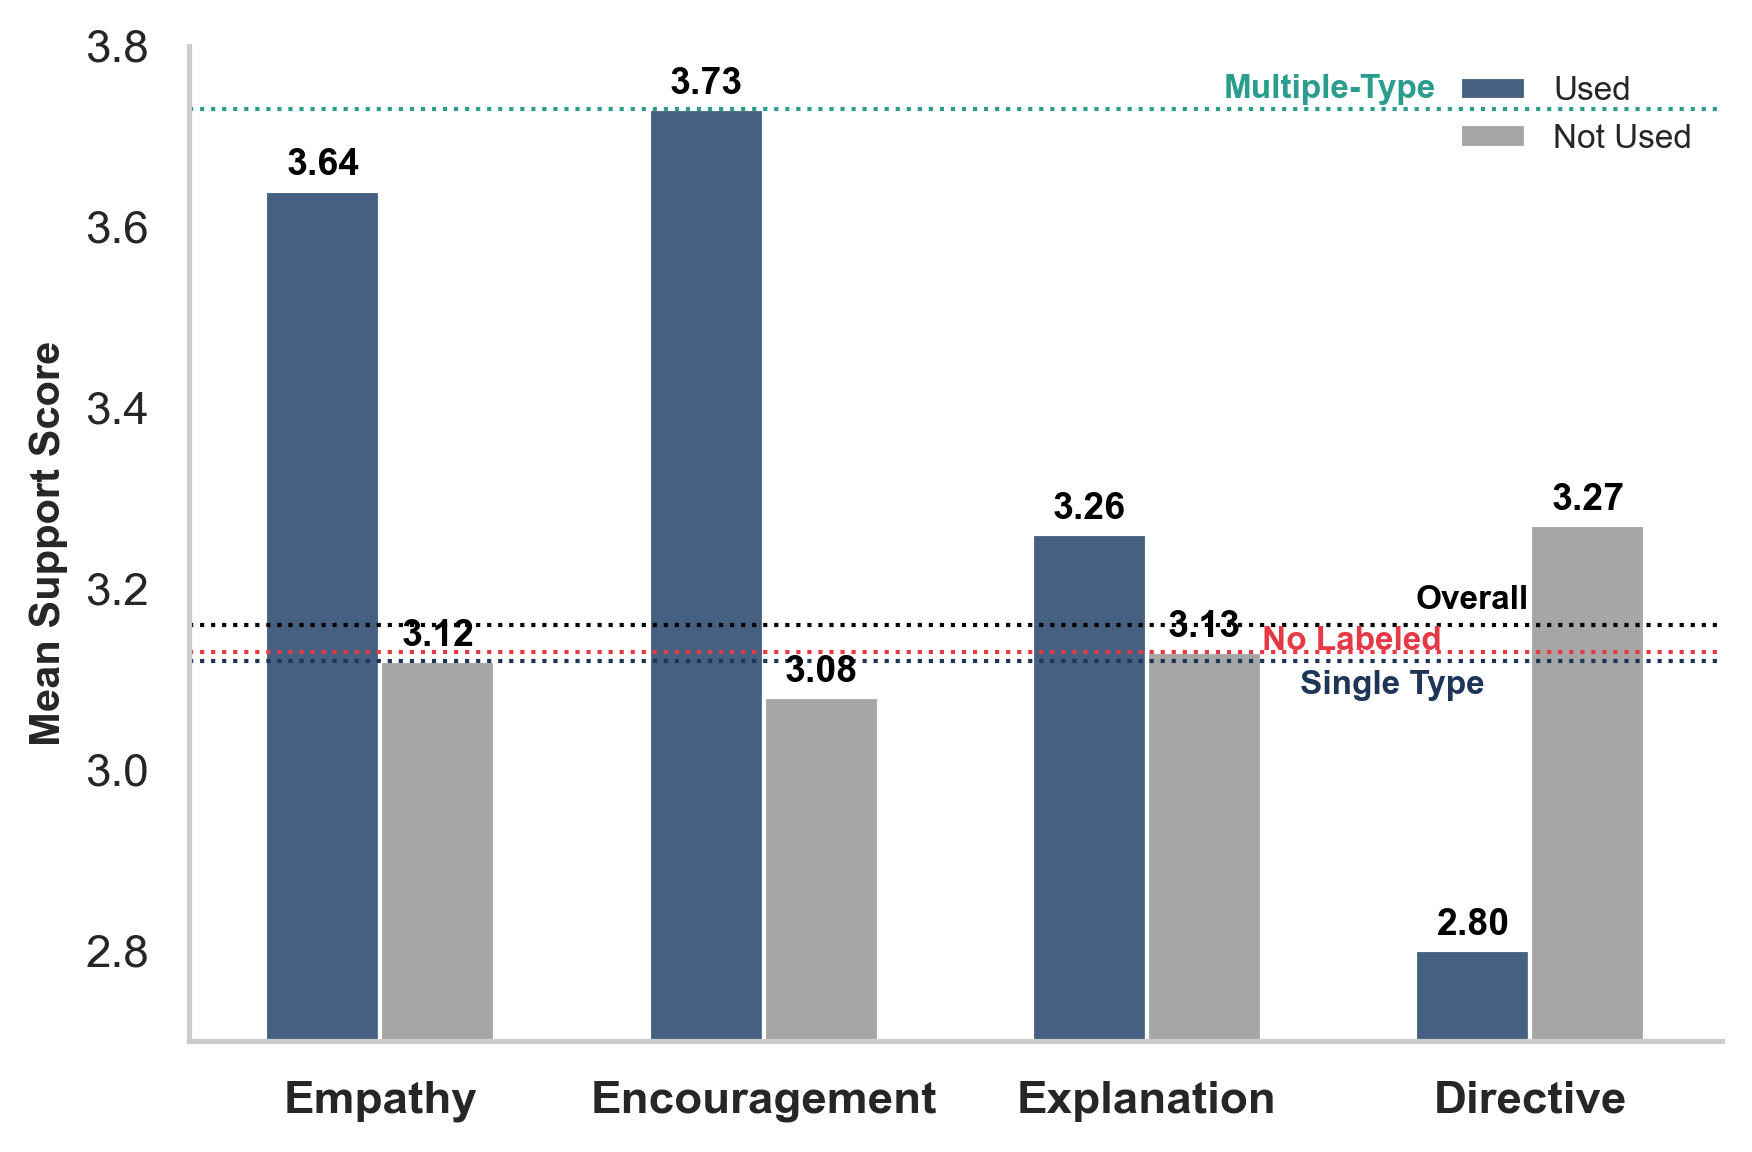

In [66]:
# Visualize the effect of different response types on perceived support scores(AVG)
plt.figure(figsize=(6,4), dpi=300)

palette = {
    "Used": "#3B5F8A",
    "Not Used": "#A6A6A6"
}

ax = sns.barplot(
    data=plot_df,
    x="Response Type",
    y="Average Support Score",
    hue="Condition",
    palette=palette,
    width=0.6
)

plt.ylim(2.7, 3.8)

# Reference lines
plt.axhline(no_label_score, linestyle=":", color="#E63946", linewidth=1)
plt.axhline(single_value, linestyle=":", color="#1D3557", linewidth=1)
plt.axhline(multi_score, linestyle=":", color="#2A9D8F", linewidth=1)
plt.axhline(overall_score, linestyle=":", color="#000000", linewidth=1)

# Annotate bar values
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=9,
        color="black",
        xytext=(0, 2),
        textcoords='offset points',
        weight="bold"
    )

# line_text
plt.text(2.3, no_label_score - 0.005, "No Labeled", color="#E63946", fontsize=8, va="bottom", fontweight="bold")
plt.text(2.4, single_value - 0.01, "Single Type", color="#1D3557", fontsize=8, va="top", fontweight="bold")
plt.text(2.2, multi_score + 0.005, "Multiple-Type", color="#2A9D8F", fontsize=8, va="bottom", fontweight="bold")
plt.text(2.7, overall_score + 0.01, "Overall", color="#000000", fontsize=8, va="bottom", fontweight="bold")

# label
#plt.title("Effect of Response Types on Perceived Support (Mean)", fontsize=11)
plt.ylabel("Mean Support Score", fontsize=10, weight="bold")
plt.xlabel("")
plt.setp(ax.get_xticklabels(), fontweight='bold')

sns.despine()

# legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], frameon=False, fontsize=8, loc="upper right")
plt.grid(axis='y', visible=False)
plt.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig("figure1.pdf", bbox_inches='tight')
plt.show()

`Summary`

Mean support scores vary clearly across response types and conditions. <b>Encouragement</b> and <b>Empathy</b> show the strongest positive association with perceived support when used, both substantially higher than when not used. <b>Explanation</b> exhibits only a modest increase, suggesting a limited effect on its own.

In contrast, <b>Directive responses</b> are associated with lower support scores when used alone. However, their effectiveness improves when combined with other response types, particularly affective ones, indicating that directive elements are not inherently unsupportive but interaction-dependent <i>(See in 3.1.2)</i>.

At the structural level, responses with <b>multiple types</b> achieve the highest average score, while <b>single-type</b> and <b>non-labeled</b> responses remain close to the overall baseline. Overall, these results suggest that affective strategies, especially when combined with other types, are more strongly associated with higher perceived support.

##### 3.1.3.2 High-Support Patterns Across Conditions

In [73]:
cols = []

# Total number of high-support responses (support_avg >= 4)
total_high = type_response[type_response["support_avg"] >= 4].shape[0]

# Function to compute statistics for a given condition
def compute_condition(name, condition):
    subset = type_response[condition]
    
    total = subset.shape[0]
    high = subset[subset["support_avg"] >= 4].shape[0]
    
    # Percentage of high-support responses within this condition
    ratio_within = round(high / total * 100, 2) if total > 0 else 0
    
    # Percentage relative to all high-support responses (global proportion)
    ratio_global = round(high / total_high * 100, 2) if total_high > 0 else 0
    
    cols.append({
        "Condition": name,
        "Total Count": total,
        "High Support Count": high,
        "High Support (%)": ratio_within,
        "High Support (Global %)": ratio_global
    })


# Compute statistics for each response type
compute_condition("Empathy", type_response["TR_Empathy"] == 1)
compute_condition("Encouragement", type_response["TR_Encouragement"] == 1)
compute_condition("Explanation", type_response["TR_Explanation"] == 1)
compute_condition("Directive", type_response["TR_Directive"] == 1)
compute_condition("No Label", type_response["TR_total"] == 0)
compute_condition("Multiple Types", type_response["TR_total"] > 1)


# Convert results to DataFrame
result_df = pd.DataFrame(cols)

# Display results
result_df.set_index("Condition")

,Total Count,High Support Count,High Support (%),High Support (Global %)
Condition,,,,
Empathy,38,20,52.63,12.66
Encouragement,63,33,52.38,20.89
Explanation,129,42,32.56,26.58
Directive,116,26,22.41,16.46
No Label,188,55,29.26,34.81
Multiple Types,30,17,56.67,10.76


**Note:** High Support (%) measures the likelihood that a response type leads to high perceived support (within-condition proportion), while High Support (Global %) reflects the distribution of high-support responses across conditions (overall contribution).


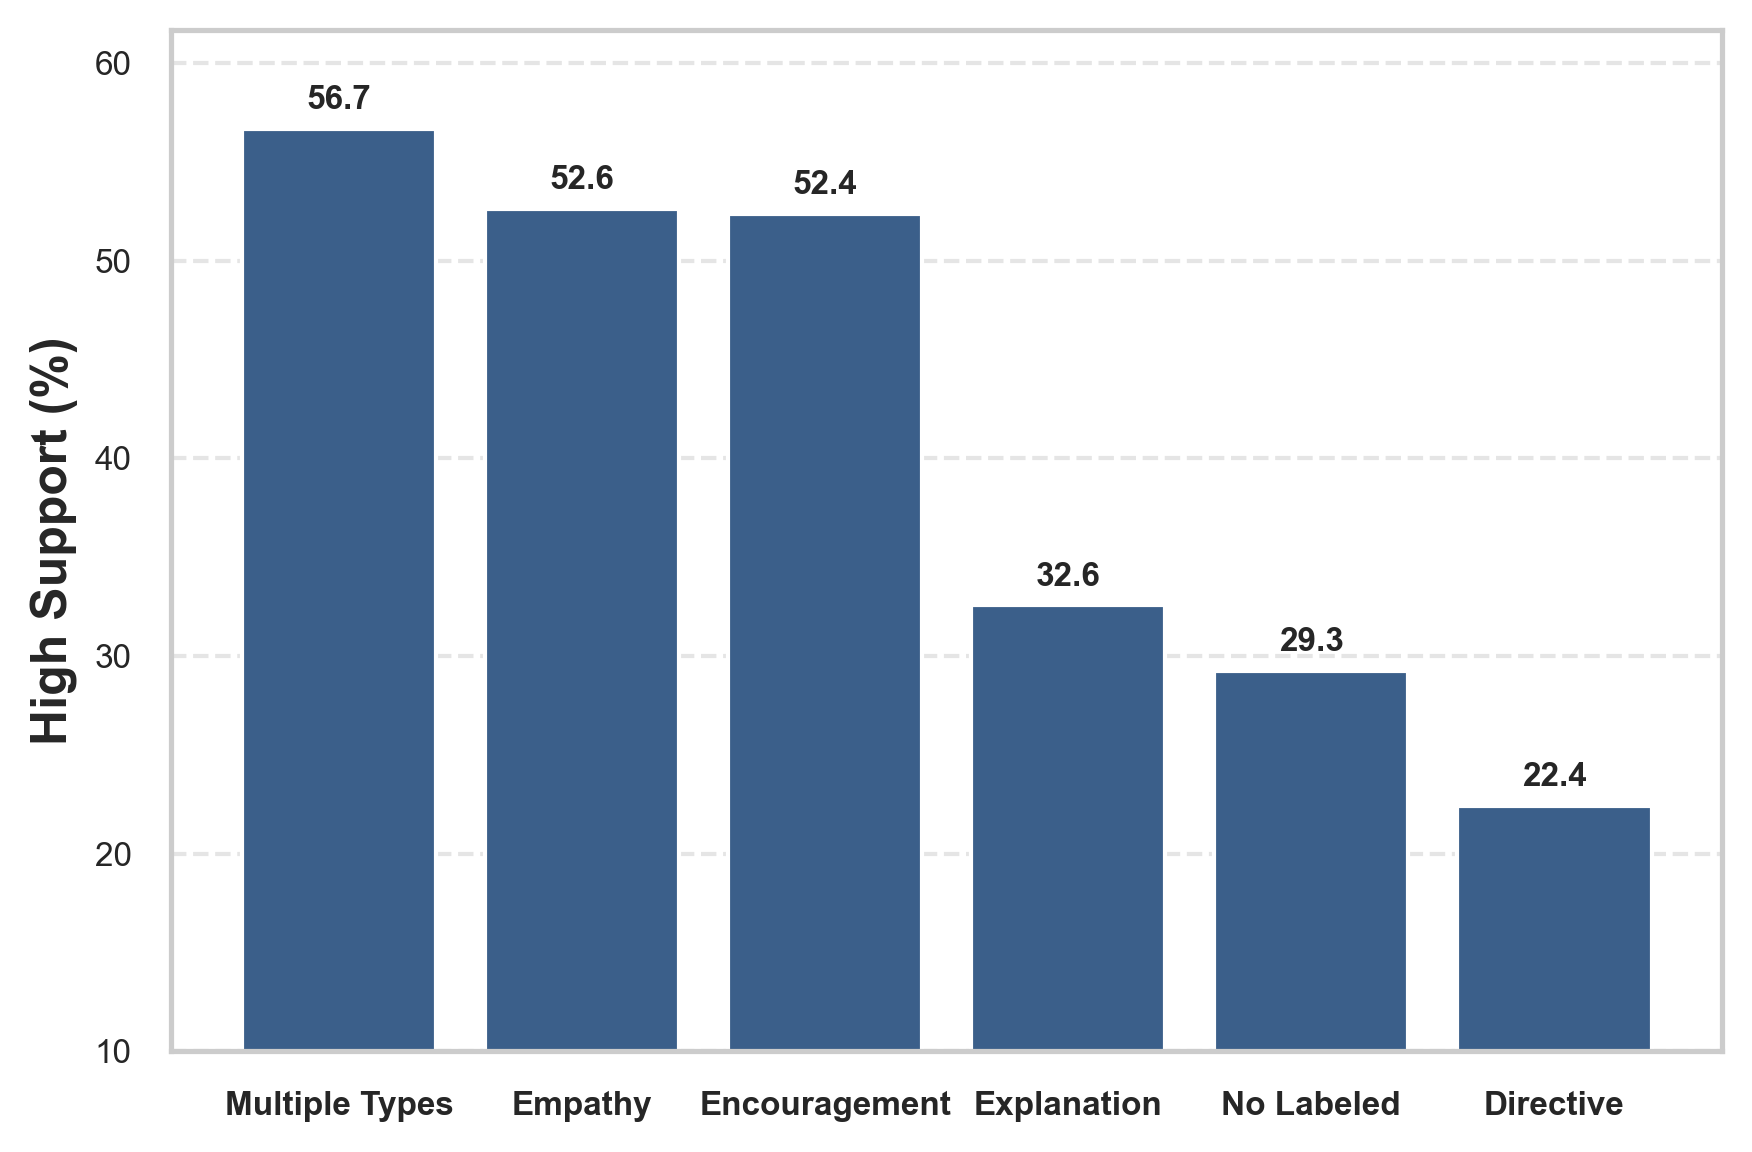

In [ ]:
# High Support (%)（effectiveness）

# Sort in descending order for clarity
df1 = result_df.sort_values("High Support (%)", ascending=False)

plt.figure(figsize=(6,4), dpi=300)

plt.bar(
    df1["Condition"],
    df1["High Support (%)"],
    color="#3B5F8A"
)

# Add value labels
for i, v in enumerate(df1["High Support (%)"]):
    plt.text(i, v + 1, f"{v:.1f}", ha='center', fontsize=8,fontweight="bold")

plt.ylabel("High Support (%)", weight="bold")
# plt.title("High Support Rate by Response Type")

plt.xticks(rotation=0, fontsize=8, fontweight="bold")
plt.ylim(10, max(df1["High Support (%)"]) + 5)
plt.yticks(fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.savefig("figure2.pdf", bbox_inches='tight')
plt.show()

`Summary`

This figure shows the proportion of high-support responses within each response type. Multiple Types yield the highest rate, followed by Empathy and Encouragement, while Explanation shows a moderate effect and Directive the lowest. This pattern indicates that affective and combined strategies are more effective in eliciting perceived emotional support than purely instructional or directive responses.

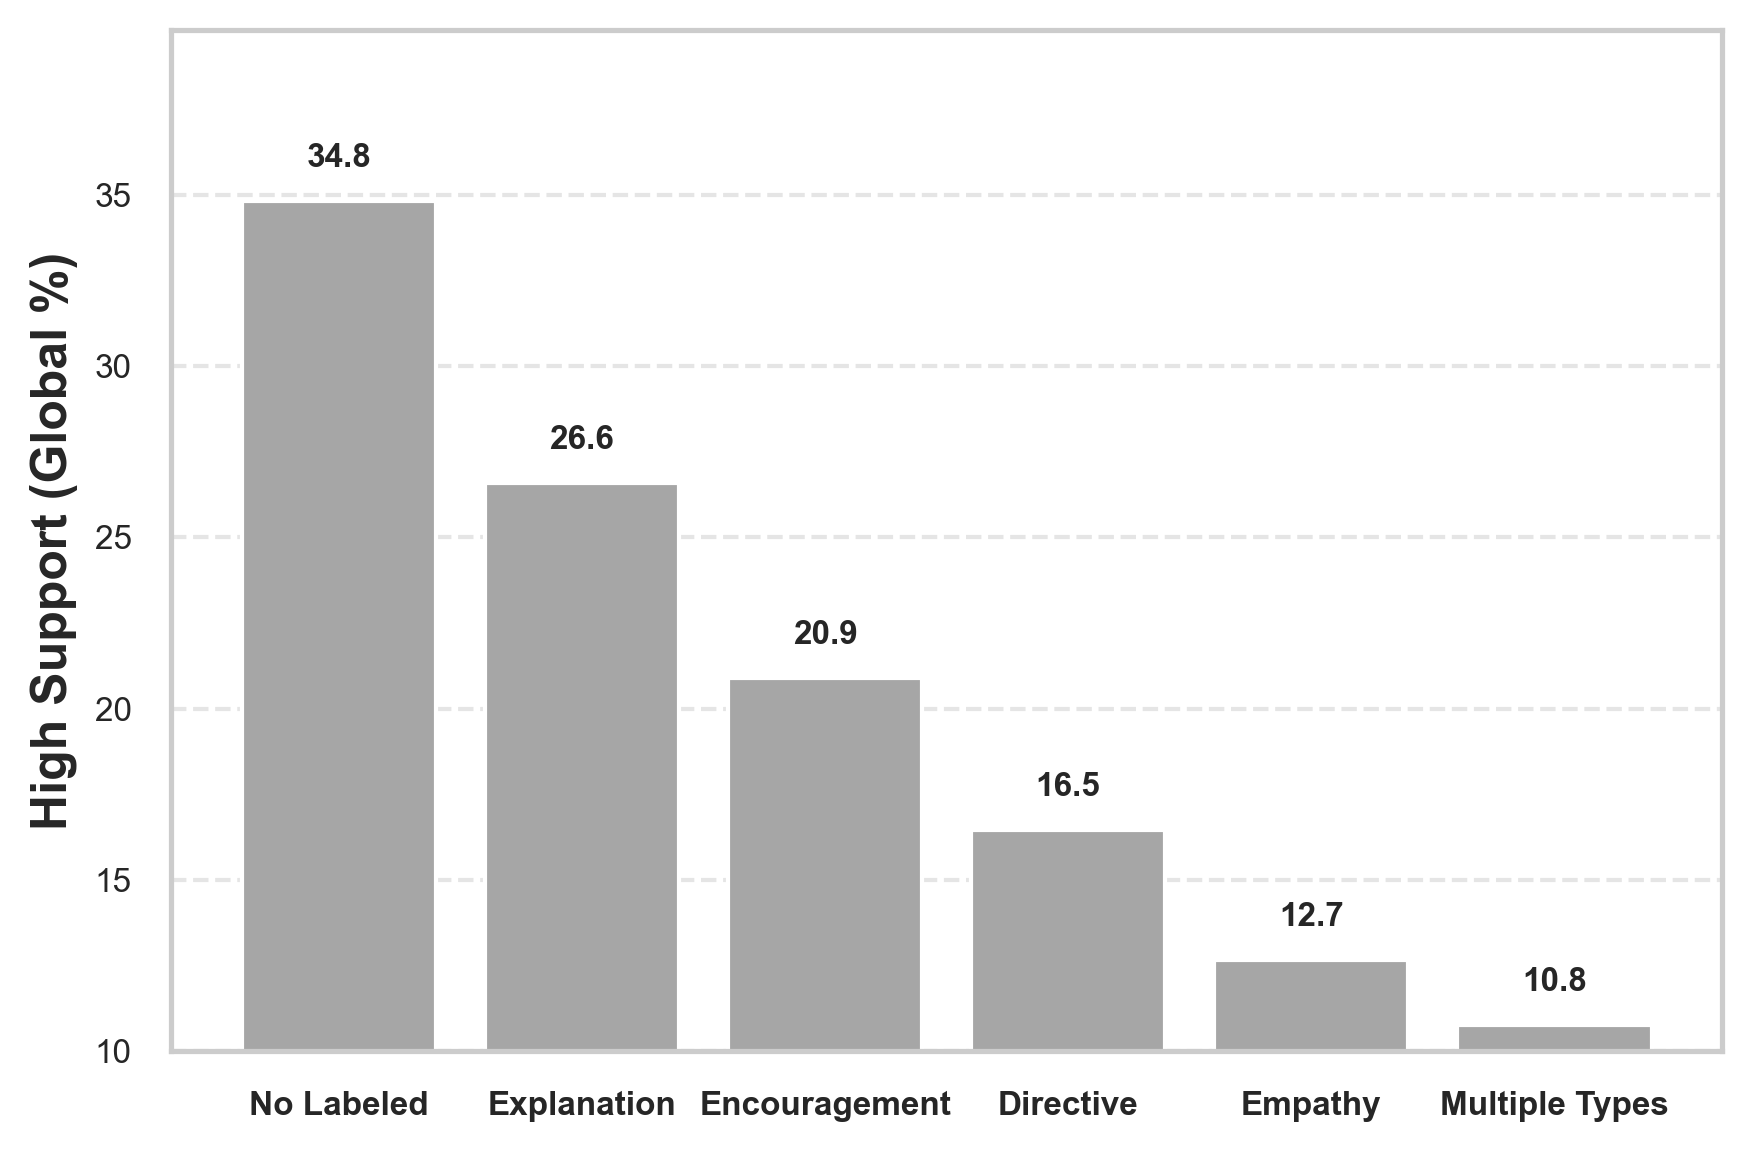

In [ ]:
# High Support (Global %)（distribution）
# Sort in descending order 
df2 = result_df.sort_values("High Support (Global %)", ascending=False)

plt.figure(figsize=(6,4), dpi=300)

plt.bar(
    df2["Condition"],
    df2["High Support (Global %)"],
    color="#A6A6A6"
)

# Add value labels
for i, v in enumerate(df2["High Support (Global %)"]):
    plt.text(i, v + 1, f"{v:.1f}", ha='center', fontsize=8, fontweight="bold")

plt.ylabel("High Support (Global %)", weight="bold")
#plt.title("Contribution to High Support Responses")

plt.xticks(rotation=0, fontsize=8, fontweight="bold")
plt.ylim(10, max(df2["High Support (Global %)"]) + 5)
plt.yticks(fontsize=8)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.grid(axis='x', visible=False)
plt.savefig("figure3.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

`Summary`

This figure shows the distribution of high-support responses across different response types.

Although Multiple Types have the highest effectiveness, their contribution is relatively low, suggesting they are not frequently used. In contrast, No Labeled responses contribute the largest share of high-support cases, likely due to their higher frequency.

The presence of high-support responses in the No Labeled category also suggests that some supportive strategies may not be captured by the current annotation scheme.

/var/folders/c8/vcr8t_yn0wq2rqnv1b7cqrvr0000gn/T/ipykernel_71551/1977498780.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df1["Condition"], rotation=0, fontsize=6, fontweight="bold")
/var/folders/c8/vcr8t_yn0wq2rqnv1b7cqrvr0000gn/T/ipykernel_71551/1977498780.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df2["Condition"], rotation=0, fontsize=7, fontweight="bold")


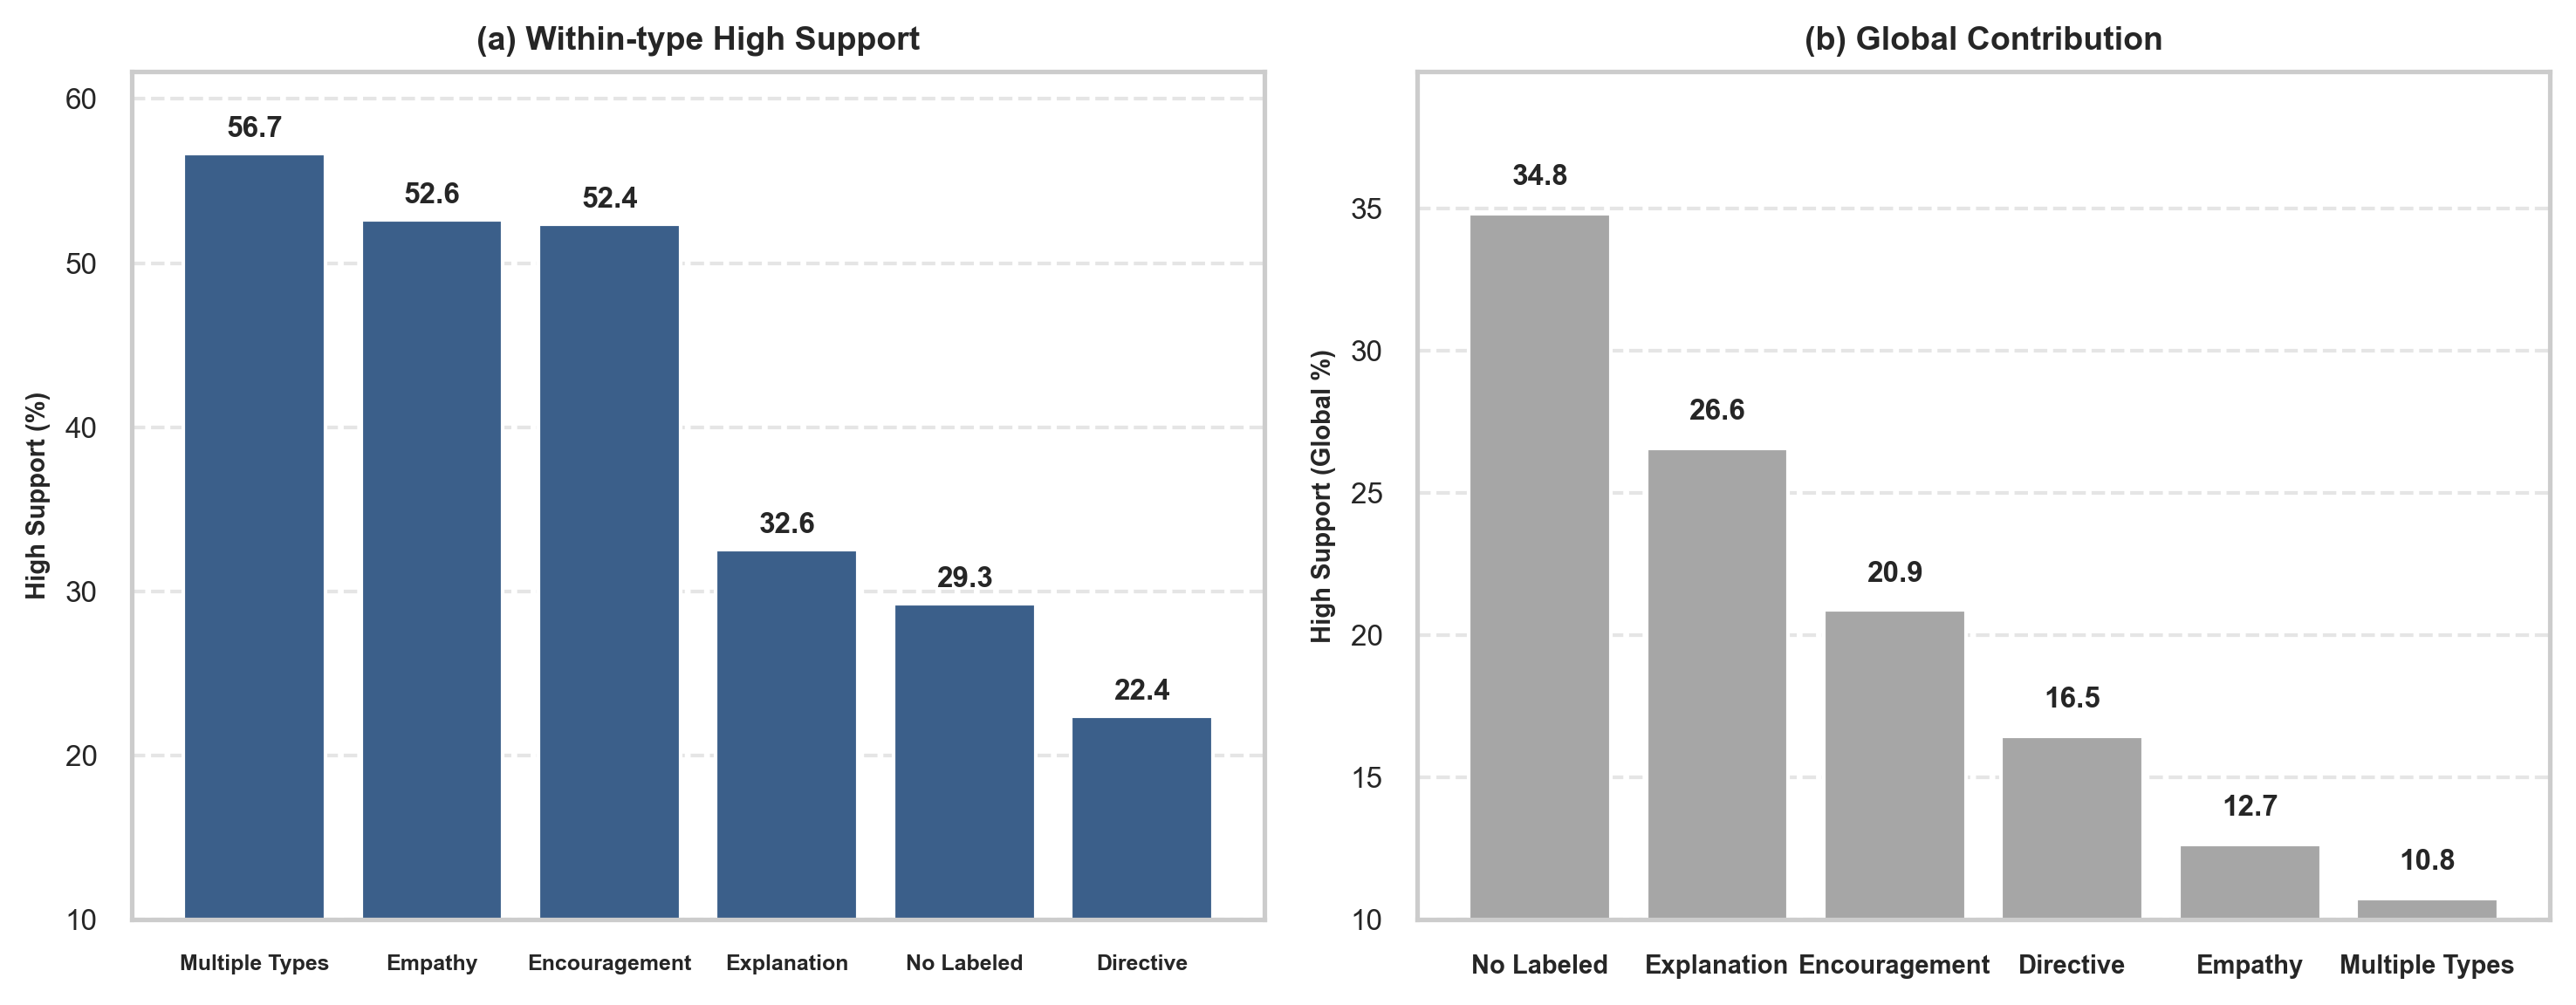

In [70]:
# Combined figure (Fig 2a + 2b)

fig, axes = plt.subplots(1, 2, figsize=(10,4), dpi=300)

# -------- (a) High Support (%) --------
df1 = result_df.sort_values("High Support (%)", ascending=False)

axes[0].bar(
    df1["Condition"],
    df1["High Support (%)"],
    color="#3B5F8A"
)

for i, v in enumerate(df1["High Support (%)"]):
    axes[0].text(i, v + 1, f"{v:.1f}", ha='center', fontsize=8, fontweight="bold")

axes[0].set_ylabel("High Support (%)", fontsize=7, weight="bold")
axes[0].set_title("(a) Within-type High Support", fontsize=9,fontweight="bold")
axes[0].set_xticklabels(df1["Condition"], rotation=0, fontsize=6, fontweight="bold")
axes[0].set_ylim(10, max(df1["High Support (%)"]) + 5)
axes[0].tick_params(axis='y', labelsize=8)

axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].grid(axis='x', visible=False)


# -------- (b) High Support (Global %) --------
df2 = result_df.sort_values("High Support (Global %)", ascending=False)

axes[1].bar(
    df2["Condition"],
    df2["High Support (Global %)"],
    color="#A6A6A6"
)

for i, v in enumerate(df2["High Support (Global %)"]):
    axes[1].text(i, v + 1, f"{v:.1f}", ha='center', fontsize=8, fontweight="bold")

axes[1].set_ylabel("High Support (Global %)", fontsize=7, weight="bold")
axes[1].set_title("(b) Global Contribution", fontsize=9,fontweight="bold")
axes[1].set_xticklabels(df2["Condition"], rotation=0, fontsize=7, fontweight="bold")
axes[1].set_ylim(10, max(df2["High Support (Global %)"]) + 5)
axes[1].tick_params(axis='y', labelsize=8)

axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].grid(axis='x', visible=False)


plt.tight_layout()
plt.savefig("figure2_combined.pdf", bbox_inches='tight')
plt.show()

In [71]:
# Check the original data of no labeled highscore
no_labeled_highscore = type_response[
    (type_response["TR_total"] == 0) &
    (type_response["support_avg"] >= 4)
]

no_labeled_highscore = no_labeled_highscore.merge(
    df[["id", "context"]],
    on="id",
    how="left"
)

no_labeled_highscore[["context", "teacher_response", "support_avg"]].head(10)

,context,teacher_response,support_avg
0,"You also make some batter to make pancakes! Oohh Is there Starbucks in Kyiv? No But I bet you've seen it in Israel? No, there is not Starbucks in Israel and Ukraine:( Ah well, I'm sure you will one day! What is fast food like in Israel?",I know about Kyiv! McDonalds and Domashnya Kukhnya!,4.0
1,I don't really understand your question '-you mean of driving or of your job?' It was my first day at work 10 years ago,Sorry I meant was it your first day driving after you passed your test or your first day at your new job but you've answered that now I see...!,4.0
2,"I think Easter in the UK is pretty much a non-event really (1% of Christmas) Time off work it's true (though that's not really relevant now of course) I see... it's quite different in Spain, especially in Andalusia. Did you like Easter events when you lived there?",Yes I remember Semana Santa in Granada the first year I was in Spain - 'full on' is the word I'd use here!,4.0
3,"could you finish the sentence, please? I'll stay at home great! what about If I ____ in the USA now, I ____ eat cheeseburgers for breakfast! Silly example, I know, just for the grammar Have been/ will How about 'If I were in the USA now, I would eat...'?",Does it sound familiar? It's ok if it doesn't!,4.5
4,maybe better right index finger I feel like and old lady talking about my health problems haha Do you play any musical instruments? Well...I played the guitar for many years from the age of 14 or so ... but I kind of gave up as i got stuck in a rut and possible had limited musical talent!,I could impress a beginner but I'm not a natural!,4.0
5,oh yes of course I forgot about that ...perfect! you can say: 'all year round' without 'the' Haha I see that your experience in Spain wasn't to healthy but I guess it was very fun Thanks for corrections,it was fun yeah! nice food cheap fags and booze so at the time I loved it!,4.5
6,In Germany then can still go out for walks with one person... I think they are much more sensible than Spanish people... yes I guess if you pick a limited number (or just one) of people and then stick with them it would be ok right? I feel bad because my daughter won't be able to play with her friends for months potentially,this is the same in Spain right? As in kids can't play with anyone?,4.0
7,"That's it! You can also say: I regret not having studied teaching - more formal but the first one very common in speaking if no danger of confusion I mean over time I see. I don't tent to use that verb Tell me more about what what you wish (about the teaching thing) if you like Sorry, I don't usually use that verb It's a common verb so sounds good less common as a noun I understand",Maybe English peoplle regret things more!,4.0
8,"Sounds cool, thanks for that! It's probably aimed at teenagers though, not young kids, right? It's teen but you need to see gameplay If you want , I can send one I'm sure I can find it, thank you! It's reassuring that there is no blood So what's the fun fact about you? :) Have you ever played star wars lego?",Yes! We like it a lot,4.0
9,plural Sorry you mean you didn't know the word policy was a noun? ways Yes good! yes.. but I studied just now is political. Yes sorry <STUDENT> just to be clear - you know the word policy means 'plan' right? But a specific plan (that a government of company/organisation has) yes..many way to solve problems ways,Yes good! So actually a useful word for IELTS,4.5


`Summary`

Some high-support responses in the No Labeled category are not task-related but show interest in students’ personal or off-topic contributions. Although such responses were not annotated under the current scheme, they may still be perceived as supportive, as interactions tailored to students’ individual interests can resonate with them and foster a sense of support. This indicates that certain forms of support are not captured by the existing categories.

In [74]:
# Filter multiple-type responses with high support (support_avg >= 4)
multi_high = multi[multi["support_avg"] >= 4].copy()

# Compute distribution of strategy combinations
combo_high = multi_high["combination"].value_counts().reset_index()
combo_high.columns = ["Combination", "Count"]

# Calculate percentage within the multiple high-support subset
combo_high["Percentage (%)"] = (
    combo_high["Count"] / combo_high["Count"].sum() * 100
).round(1)

# Set combination as index for display
combo_high.set_index("Combination")

,Count,Percentage (%)
Combination,,
"(TR_Encouragement, TR_Explanation)",6,35.3
"(TR_Encouragement, TR_Directive)",4,23.5
"(TR_Empathy, TR_Explanation)",3,17.6
"(TR_Empathy, TR_Encouragement)",2,11.8
"(TR_Empathy, TR_Explanation, TR_Directive)",1,5.9
"(TR_Empathy, TR_Directive)",1,5.9


`Summary`

Some combinations involving affective strategies (e.g., encouragement + explanation) appear to show higher support rates than those dominated by directive elements, although this observation is limited by small sample sizes.

`Summary for Hight-Support Patterns`

Overall, perceived emotional support is influenced by both individual response types and their combinations: affective response types and their combinations tend to be more effective in eliciting support, while non-labeled responses contribute substantially due to their frequency, indicating both usage patterns and limitations in the current annotation scheme.

## 3.2 Statistical Testing (t-tests)

**Empathy**

In [75]:
from scipy.stats import ttest_ind

# Mean support scores (from aggregated table)
mean_not_used = TR_Em_score.iloc[0]["Average_Support_Score"]
mean_used = TR_Em_score.iloc[1]["Average_Support_Score"]

# Extract raw support scores for t-test comparison
used = type_response[type_response["TR_Empathy"] == 1]["support_avg"]
not_used = type_response[type_response["TR_Empathy"] == 0]["support_avg"]

# Perform independent t-test (Welch’s t-test, unequal variances)
t_stat, p_value = ttest_ind(used, not_used, equal_var=False)

# Display results
print("Mean (Using Empathy):", round(mean_used, 2))
print("Mean (Not Using Empathy):", round(mean_not_used, 2))
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

Mean (Using Empathy): 3.64
Mean (Not Using Empathy): 3.12
t = 3.460, p = 0.0012


`Summary`

The average support score is higher when Empathy is used (M = 3.64) compared to when it is not used (M = 3.12), and this difference is statistically significant (t = 3.46, p = 0.0012).

**Encouragement**

In [ ]:
# Mean support scores (from aggregated table)
mean_not_used = TR_Ec_score.iloc[0]["Average_Support_Score"]
mean_used = TR_Ec_score.iloc[1]["Average_Support_Score"]

# Extract raw support scores for t-test comparison
used = type_response[type_response["TR_Encouragement"] == 1]["support_avg"]
not_used = type_response[type_response["TR_Encouragement"] == 0]["support_avg"]

# Perform independent t-test (Welch’s t-test, unequal variances)
t_stat, p_value = ttest_ind(used, not_used, equal_var=False)

# Display results
print("Mean (Using Encouragement):", round(mean_used, 2))
print("Mean (Not Using Encouragement):", round(mean_not_used, 2))
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

Mean (Using Encouragement): 3.73
Mean (Not Using Encouragement): 3.08
t = 5.940, p = 0.0000


`Summary`

The average support score is higher when Encouragement is used (M = 3.73) compared to when it is not used (M = 3.08), and this difference is highly statistically significant (t = 5.94, p < 0.001).

**Explanation**

In [ ]:
# Mean support scores (from aggregated table)
mean_not_used = TR_Ex_score.iloc[0]["Average_Support_Score"]
mean_used = TR_Ex_score.iloc[1]["Average_Support_Score"]

# Extract raw support scores for t-test comparison
used = type_response[type_response["TR_Explanation"] == 1]["support_avg"]
not_used = type_response[type_response["TR_Explanation"] == 0]["support_avg"]

# Perform independent t-test (Welch’s t-test, unequal variances)
t_stat, p_value = ttest_ind(used, not_used, equal_var=False)

# Display results
print("Mean (Using Explanation):", round(mean_used, 2))
print("Mean (Not Using Explanation):", round(mean_not_used, 2))
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

Mean (Using Explanation): 3.26
Mean (Not Using Explanation): 3.13
t = 1.318, p = 0.1886


`Summary` 

The difference between responses with and without <b>Explanation</b> is not statistically significant (p = 0.19), suggesting that explanation alone does not strongly influence perceived support.

**Directive**

In [ ]:
# Mean support scores (from aggregated table)
mean_not_used = TR_Dr_score.iloc[0]["Average_Support_Score"]
mean_used = TR_Dr_score.iloc[1]["Average_Support_Score"]

# Extract raw support scores for t-test comparison
used = type_response[type_response["TR_Directive"] == 1]["support_avg"]
not_used = type_response[type_response["TR_Directive"] == 0]["support_avg"]

# Perform independent t-test (Welch’s t-test, unequal variances)
t_stat, p_value = ttest_ind(used, not_used, equal_var=False)

# Display results
print("Mean (Using Directive):", round(mean_used, 2))
print("Mean (Not Using Directive):", round(mean_not_used, 2))
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

Mean (Using Directive): 2.8
Mean (Not Using Directive): 3.27
t = -4.292, p = 0.0000


`Summary`

The average support score is lower when <b>Directive</b> is used (M = 2.80) compared to when it is not used (M = 3.27), and this difference is statistically significant (t = -4.29, p < 0.001).

`Summary for the whole t-tests`

Affective response types such as Encouragement and Empathy are significantly associated with higher perceived support, while Directive responses show a significant negative association. In contrast, Explanation does not exhibit a significant effect, suggesting that informational content alone may not be sufficient to enhance perceived support.

## 3.3 Regression Analysis

In [ ]:
import statsmodels.api as sm

X = type_response[[
    "TR_Empathy",
    "TR_Encouragement",
    "TR_Explanation",
    "TR_Directive"
]]

y = type_response["support_avg"]

# Add intercept term
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            support_avg   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     14.21
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           5.43e-11
Time:                        15:53:11   Log-Likelihood:                -678.74
No. Observations:                 503   AIC:                             1367.
Df Residuals:                     498   BIC:                             1389.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.1037      0.065  

`Summary` 

A linear regression analysis was conducted to examine the independent effects of response types on perceived support. The results show that Encouragement (β = 0.66, p < 0.001) and Empathy (β = 0.51, p = 0.002) are significantly associated with higher support scores, while Directive responses are associated with lower support (β = −0.38, p < 0.001). In contrast, Explanation does not show a significant effect (p = 0.35). These findings are consistent with the descriptive and t-test results, indicating that affective response types have a stronger positive association with perceived support than instructional or directive ones.

## 4 Linguistic Patterns in High-Support Responses

### 4.1 Length and Structural Features

In [52]:
type_response["length"] = type_response["teacher_response"].str.split().apply(len)

type_response["high_support"] = (type_response["support_avg"] >= 4).astype(int)

In [53]:
length_summary = (
    type_response
    .groupby("high_support", as_index=False)
    .agg(Avg_Length=("length", "mean"))
)

length_summary["Support Level"] = length_summary["high_support"].map({
    0: "Low Support",
    1: "High Support"
})

length_summary = (
    length_summary
    .drop(columns="high_support")
    .round(2)
)
length_summary.set_index("Support Level")

,Avg_Length
Support Level,
Low Support,12.53
High Support,14.68


In [54]:
from scipy.stats import ttest_ind

high = type_response[type_response["high_support"] == 1]["length"]
low = type_response[type_response["high_support"] == 0]["length"]

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print(f"High Support Avg Length: {high.mean():.2f}")
print(f"Low Support Avg Length: {low.mean():.2f}")
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

High Support Avg Length: 14.68
Low Support Avg Length: 12.53
t = 2.627, p = 0.0091


`Summary`

High-support responses are longer on average (M = 14.68) than low-support responses (M = 12.53), and this difference is statistically significant (t = 2.63, p = 0.009), suggesting that more elaborated responses may contribute to higher perceived support.

### 4.2 Affective and Politeness Markers

**affective marks** 

In [55]:
affective_words = [
    "good", "great", "nice", "well done", "interesting",
    "i understand", "i see", "don't worry", "no worries",
    "you’re right", "that's right", "exactly"
]

In [56]:
type_response["response_lower"] = type_response["teacher_response"].str.lower()

In [57]:
type_response["has_affective"] = type_response["response_lower"].apply(
    lambda x: any(word in x for word in affective_words)
).astype(int)

In [58]:
aff_summary = (
    type_response
    .groupby("high_support", as_index=False)
    .agg(Affective_Rate=("has_affective", "mean"))
)

aff_summary["Support Level"] = aff_summary["high_support"].map({
    0: "Low Support",
    1: "High Support"
})

aff_summary["Affective_Rate"] = (aff_summary["Affective_Rate"] * 100).round(2)

aff_summary = aff_summary.drop(columns="high_support")
aff_summary.set_index("Support Level")

,Affective_Rate
Support Level,
Low Support,22.03
High Support,35.44


In [59]:
high = type_response[type_response["high_support"] == 1]["has_affective"]
low = type_response[type_response["high_support"] == 0]["has_affective"]

from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print(f"High Support Affective Rate: {high.mean()*100:.2f}%")
print(f"Low Support Affective Rate: {low.mean()*100:.2f}%")
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

High Support Affective Rate: 35.44%
Low Support Affective Rate: 22.03%
t = 3.032, p = 0.0027


`Summary`

High-support responses contain affective language more frequently (35.44%) than low-support responses (22.03%), and this difference is statistically significant (t = 3.03, p = 0.003), indicating that emotionally supportive expressions are associated with higher perceived support.

**Politeness Markers**

In [60]:
politeness_words = [
    "please", "thank you", "thanks",
    "could you", "can you", "would you",
    "let's", "shall we",
    "you might", "you could",
    "feel free", "i suggest", "i recommend"
]

In [61]:
type_response["has_politeness"] = type_response["response_lower"].apply(
    lambda x: any(word in x for word in politeness_words)
).astype(int)

In [62]:
pol_summary = (
    type_response
    .groupby("high_support", as_index=False)
    .agg(Politeness_Rate=("has_politeness", "mean"))
)

pol_summary["Support Level"] = pol_summary["high_support"].map({
    0: "Low Support",
    1: "High Support"
})

pol_summary["Politeness_Rate"] = (pol_summary["Politeness_Rate"] * 100).round(2)

pol_summary = pol_summary.drop(columns="high_support")
pol_summary.set_index("Support Level")

,Politeness_Rate
Support Level,
Low Support,10.14
High Support,14.56


In [63]:
from scipy.stats import ttest_ind

high = type_response[type_response["high_support"] == 1]["has_politeness"]
low = type_response[type_response["high_support"] == 0]["has_politeness"]

t_stat, p_value = ttest_ind(high, low, equal_var=False)

print(f"High Support Politeness Rate: {high.mean()*100:.2f}%")
print(f"Low Support Politeness Rate: {low.mean()*100:.2f}%")
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

High Support Politeness Rate: 14.56%
Low Support Politeness Rate: 10.14%
t = 1.357, p = 0.1760


`Summary` 

Politeness-related expressions appear slightly more frequently in high-support responses (14.56%) than in low-support responses (10.14%), but the difference is not statistically significant (p = 0.18), suggesting that politeness alone may not play a decisive role in perceived support.